In [1]:
import os
os.environ["KERAS_BACKEND"]="tensorflow"
import keras
from keras import layers

In [16]:
import regex as re
def split_chars(text):
    return re.findall(r".",text)
chars= split_chars("The quick brown fox jumped over the lazy dog.")
chars[:12]


['T', 'h', 'e', ' ', 'q', 'u', 'i', 'c', 'k', ' ', 'b', 'r']

In [17]:
import regex as re
def split_words(text):
    return re.findall(r"[\w]+|[.,!?;]",text)
words= split_words("The quick brown fox jumped over the lazy dog.")
words[:12]

['The', 'quick', 'brown', 'fox', 'jumped', 'over', 'the', 'lazy', 'dog', '.']

In [20]:
vocabulary={
    "[UNK]": 0,
    "the":1,
    "quick":2,
    "brown":3,
    "fox":4,
    "jumped":5,
    "over":6,
    "dog":7,
    ".": 8,
}
words= split_words("The quick brown fox jumped over the lazy dog.")
indices= [vocabulary.get(word,0) for word in words]

In [21]:
indices

[0, 2, 3, 4, 5, 6, 1, 0, 7, 8]

In [55]:
class CharTokenizer:
    def __init__(self,vocabulary):
        self.vocabulary= vocabulary
        self.unk_id=vocabulary["[UNK]"]

    def standardize(self, inputs):
        return inputs.lower()

    def split(self, inputs):
        return re.findall(r".", inputs)
        
    def index(self,tokens):
        return [self.vocabulary.get(t, self.unk_id) for t in tokens]

    def __call__(self,inputs):
        inputs= self.standardize(inputs)
        tokens= self.split(inputs)
        indices= self.index(tokens)
        return indices



In [56]:
import collections 

def compute_char_vocabulary(inputs, max_size):
    char_counts= collections.Counter()
    for x in inputs:
        x= x.lower()
        tokens= re.findall(r".",x)
        char_counts.update(tokens)
    vocabulary= ["[UNK]"]
    most_common= char_counts.most_common(max_size- len(vocabulary))
    for token, count in most_common:
        vocabulary.append(token)
    return dict((token,i) for i, token in enumerate(vocabulary))

In [92]:
class WordTokenizer:
    def __init__(self,vocabulary):
        self.vocabulary= vocabulary
        self.unk_id= vocabulary["[UNK]"]

    def standardize(self, inputs):
        return inputs.lower()

    def split(self, inputs):
        return re.findall(r"[\w]+|[.,!?;]", inputs)
        
    def index(self,tokens):
        return [self.vocabulary.get(t, self.unk_id) for t in tokens]

    def __call__(self,inputs):
        inputs= self.standardize(inputs)
        tokens= self.split(inputs)
        indices= self.index(tokens)
        return indices



In [93]:
def compute_word_vocabulary(inputs, max_size):
    word_counts= collections.Counter()
    for x in inputs:
        x= x.lower()
        tokens= re.findall(r"[\w]+|[.,!?;]",x)
        word_counts.update(tokens)
    vocabulary= ["[UNK]"]
    most_common= word_counts.most_common(max_size- len(vocabulary))
    for token, count in most_common:
        vocabulary.append(token)
    return dict((token,i) for i, token in enumerate(vocabulary))

In [ ]:
import os
os.environ["KERAS_BACKEND"]="tensorflow"
import keras

filenames= keras.utils.get_file(
    origin="https://www.gutenberg.org/cache/epub/2701/pg2701.txt"
)
moby_dick= list(open(filenames, "r"))
vocabulary= compute_char_vocabulary(moby_dick, max_size=100)
char_tokenizer= CharTokenizer(vocabulary)

In [95]:
print("vocab length:" , len(vocabulary))

vocab length: 79


In [96]:
print("Vocabulary start:", list(vocabulary.keys())[:10])

Vocabulary start: ['[UNK]', ' ', 'e', 't', 'a', 'o', 'n', 'i', 's', 'h']


In [97]:
print("Vocabulary end:", list(vocabulary.keys())[-10:])

Vocabulary end: ['ו', '\u200e', 'ϰ', 'η', 'τ', 'ο', 'ς', 'â', '%', '+']


In [98]:
print("Line length:" , len(char_tokenizer(
    "Call me Ishmael. Some years ago--never mind how long precisely."
)))

Line length: 63


In [99]:
vocabulary= compute_word_vocabulary(moby_dick, max_size= 2_000)
word_tokenizer= WordTokenizer(vocabulary)

In [100]:
print("vocab length:" , len(vocabulary))

vocab length: 2000


In [101]:
print("Vocabulary start:", list(vocabulary.keys())[:10])

Vocabulary start: ['[UNK]', ',', 'the', '.', 'of', 'and', 'a', 'to', 'in', ';']


In [102]:
print("Vocabulary end:", list(vocabulary.keys())[-10:])

Vocabulary end: ['features', 'barbaric', 'helmsman', 'temporary', 'indispensable', 'fashion', 'lovely', 'steadily', 'fastened', 'birds']


In [103]:
print("Line length:" , len(word_tokenizer(
    "Call me Ishmael. Some years ago--never mind how long precisely."
)))

Line length: 13


In [155]:
data=[
    "the quick brown fox",
    "the slow brown fox",
    "the quick brown foxhound",
]


In [156]:
def count_and_split_words(data):
    counts= collections.Counter()
    for line in data:
        line= line.lower()
        for word in re.findall(r"[\w]+|[.,!?;]",line):
            chars= re.findall(r".",word)
            split_word=" ".join(chars)
            counts[split_word]+=1
    return dict(counts)
counts= count_and_split_words(data)

In [157]:
counts

{'t h e': 3,
 'q u i c k': 2,
 'b r o w n': 3,
 'f o x': 2,
 's l o w': 1,
 'f o x h o u n d': 1}

In [153]:
def count_pairs(counts):
    pairs= collections.Counter()
    for word, freq in counts.items():
        symbols= word.split()
        for pair in zip(symbols[:-1],symbols[1:]):
            pairs[pair] += freq
    return pairs

def merge_pairs(counts, first,second):
    split= re.compile(f"{re.escape(first)} {re.escape(second)}")
    merged= f"{first}{second}"
    return {split.sub(merged,word): count for word,count in counts.items()}

for i in range(10):
    pairs= count_pairs(counts)
    first, second= max(pairs,key=pairs.get)
    counts= merge_pairs(counts, first,second)
    print(list(counts.keys()))

['t h e', 'q u i c k', 'b r ow n', 'f o x', 's l ow', 'f o x h o u n d']
['th e', 'q u i c k', 'b r ow n', 'f o x', 's l ow', 'f o x h o u n d']
['the', 'q u i c k', 'b r ow n', 'f o x', 's l ow', 'f o x h o u n d']
['the', 'q u i c k', 'br ow n', 'f o x', 's l ow', 'f o x h o u n d']
['the', 'q u i c k', 'brow n', 'f o x', 's l ow', 'f o x h o u n d']
['the', 'q u i c k', 'brown', 'f o x', 's l ow', 'f o x h o u n d']
['the', 'q u i c k', 'brown', 'fo x', 's l ow', 'fo x h o u n d']
['the', 'q u i c k', 'brown', 'fox', 's l ow', 'fox h o u n d']
['the', 'qu i c k', 'brown', 'fox', 's l ow', 'fox h o u n d']
['the', 'qui c k', 'brown', 'fox', 's l ow', 'fox h o u n d']


In [158]:
def count_pairs(counts):
    pairs = collections.Counter()
    for word, freq in counts.items():
        symbols = word.split()
        for pair in zip(symbols[:-1], symbols[1:]):
            pairs[pair] += freq
    return pairs

def merge_pair(counts, first, second):
    split = re.compile(f"(?<!\S){first} {second}(?!\S)")
    merged = f"{first}{second}"
    return {split.sub(merged, word): count for word, count in counts.items()}

for i in range(10):
    pairs = count_pairs(counts)
    first, second = max(pairs, key=pairs.get)
    counts = merge_pair(counts, first, second)
    print(list(counts.keys()))

['t h e', 'q u i c k', 'b r ow n', 'f o x', 's l ow', 'f o x h o u n d']
['th e', 'q u i c k', 'b r ow n', 'f o x', 's l ow', 'f o x h o u n d']
['the', 'q u i c k', 'b r ow n', 'f o x', 's l ow', 'f o x h o u n d']
['the', 'q u i c k', 'br ow n', 'f o x', 's l ow', 'f o x h o u n d']
['the', 'q u i c k', 'brow n', 'f o x', 's l ow', 'f o x h o u n d']
['the', 'q u i c k', 'brown', 'f o x', 's l ow', 'f o x h o u n d']
['the', 'q u i c k', 'brown', 'fo x', 's l ow', 'fo x h o u n d']
['the', 'q u i c k', 'brown', 'fox', 's l ow', 'fox h o u n d']
['the', 'qu i c k', 'brown', 'fox', 's l ow', 'fox h o u n d']
['the', 'qui c k', 'brown', 'fox', 's l ow', 'fox h o u n d']


<>:10: SyntaxWarning: invalid escape sequence '\S'
<>:10: SyntaxWarning: invalid escape sequence '\S'
<>:10: SyntaxWarning: invalid escape sequence '\S'
<>:10: SyntaxWarning: invalid escape sequence '\S'
/var/folders/fd/q06hydb930q2vm8qvxyqkp700000gn/T/ipykernel_61661/2139356449.py:10: SyntaxWarning: invalid escape sequence '\S'
  split = re.compile(f"(?<!\S){first} {second}(?!\S)")
/var/folders/fd/q06hydb930q2vm8qvxyqkp700000gn/T/ipykernel_61661/2139356449.py:10: SyntaxWarning: invalid escape sequence '\S'
  split = re.compile(f"(?<!\S){first} {second}(?!\S)")


In [159]:
def compute_sub_word_vocabulary(dataset, vocab_size):
    counts = count_and_split_words(dataset)

    char_counts = collections.Counter()
    for word in counts:
        for char in word.split():
            char_counts[char] += counts[word]
    most_common = char_counts.most_common()
    vocab = ["[UNK]"] + [char for char, freq in most_common]
    merges = []

    while len(vocab) < vocab_size:
        pairs = count_pairs(counts)
        if not pairs:
            break
        first, second = max(pairs, key=pairs.get)
        counts = merge_pair(counts, first, second)
        vocab.append(f"{first}{second}")
        merges.append(f"{first} {second}")

    vocab = dict((token, index) for index, token in enumerate(vocab))
    merges = dict((token, rank) for rank, token in enumerate(merges))
    return vocab, merges

In [161]:
class SubWordTokenizer:
    def __init__(self, vocabulary, merges):
        self.vocabulary = vocabulary
        self.merges = merges
        self.unk_id = vocabulary["[UNK]"]

    def standardize(self, inputs):
        return inputs.lower()

    def bpe_merge(self, word):
        while True:
            pairs = re.findall(r"(?<!\S)\S+ \S+(?!\S)", word, overlapped=True)
            if not pairs:
                break
            best = min(pairs, key=lambda pair: self.merges.get(pair, 1e9))
            if best not in self.merges:
                break
            first, second = best.split()
            split = re.compile(f"(?<!\S){first} {second}(?!\S)")
            merged = f"{first}{second}"
            word = split.sub(merged, word)
        return word

    def split(self, inputs):
        tokens = []
        for word in re.findall(r"[\w]+|[.,!?;]", inputs):
            word = " ".join(re.findall(r".", word))
            word = self.bpe_merge(word)
            tokens.extend(word.split())
        return tokens

    def index(self, tokens):
        return [self.vocabulary.get(t, self.unk_id) for t in tokens]

    def __call__(self, inputs):
        inputs = self.standardize(inputs)
        tokens = self.split(inputs)
        indices = self.index(tokens)
        return indices

<>:19: SyntaxWarning: invalid escape sequence '\S'
<>:19: SyntaxWarning: invalid escape sequence '\S'
<>:19: SyntaxWarning: invalid escape sequence '\S'
<>:19: SyntaxWarning: invalid escape sequence '\S'
/var/folders/fd/q06hydb930q2vm8qvxyqkp700000gn/T/ipykernel_61661/759452212.py:19: SyntaxWarning: invalid escape sequence '\S'
  split = re.compile(f"(?<!\S){first} {second}(?!\S)")
/var/folders/fd/q06hydb930q2vm8qvxyqkp700000gn/T/ipykernel_61661/759452212.py:19: SyntaxWarning: invalid escape sequence '\S'
  split = re.compile(f"(?<!\S){first} {second}(?!\S)")


In [162]:
vocabulary, merges = compute_sub_word_vocabulary(moby_dick, 2_000)
sub_word_tokenizer = SubWordTokenizer(vocabulary, merges)

In [163]:
 print("Vocabulary length:", len(vocabulary))

Vocabulary length: 2000


In [164]:
print("Vocabulary start:", list(vocabulary.keys())[:10])

Vocabulary start: ['[UNK]', 'e', 't', 'a', 'o', 'n', 'i', 's', 'h', 'r']


In [165]:
print("Vocabulary end:", list(vocabulary.keys())[-7:])

Vocabulary end: ['mariners', 'height', 'certainly', 'sor', 'sist', 'similar', 'aught']


In [2]:
import os, pathlib, shutil, random

zip_path= keras.utils.get_file(
    origin= "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz",
    extract=True,
)
imdb_extract_dir= pathlib.Path(zip_path)/ "aclImdb"

In [3]:
for path in imdb_extract_dir.glob("*/*"):
    if path.is_dir():
        print(path)

/Users/muhammedimaad/.keras/datasets/aclImdb_v1.tar.gz/aclImdb/test/neg
/Users/muhammedimaad/.keras/datasets/aclImdb_v1.tar.gz/aclImdb/test/pos
/Users/muhammedimaad/.keras/datasets/aclImdb_v1.tar.gz/aclImdb/train/neg
/Users/muhammedimaad/.keras/datasets/aclImdb_v1.tar.gz/aclImdb/train/unsup
/Users/muhammedimaad/.keras/datasets/aclImdb_v1.tar.gz/aclImdb/train/pos


In [4]:
print(open(imdb_extract_dir/"train"/"pos"/"4077_10.txt","r").read())

I first saw this back in the early 90s on UK TV, i did like it then but i missed the chance to tape it, many years passed but the film always stuck with me and i lost hope of seeing it TV again, the main thing that stuck with me was the end, the hole castle part really touched me, its easy to watch, has a great story, great music, the list goes on and on, its OK me saying how good it is but everyone will take there own best bits away with them once they have seen it, yes the animation is top notch and beautiful to watch, it does show its age in a very few parts but that has now become part of it beauty, i am so glad it has came out on DVD as it is one of my top 10 films of all time. Buy it or rent it just see it, best viewing is at night alone with drink and food in reach so you don't have to stop the film.<br /><br />Enjoy


In [5]:
train_dir= pathlib.Path("imdb_train")
test_dir= pathlib.Path("imdb_test")
val_dir= pathlib.Path("imdb_val")

shutil.copytree(imdb_extract_dir/"test",test_dir)

val_percentage= 0.2
for category in ("neg","pos"):
    src_dir= imdb_extract_dir/"train"/category
    src_files= os.listdir(src_dir)
    random.Random(1337).shuffle(src_files)
    num_val_samples= int(len(src_files)*val_percentage)

    os.makedirs(val_dir/category)
    for file in src_files[:num_val_samples]:
        shutil.copy(src_dir/file, val_dir/category/file)
    os.makedirs(train_dir/category)
    for file in src_files[num_val_samples:]:
        shutil.copy(src_dir/file, train_dir/category/file)

In [8]:
from keras.utils import text_dataset_from_directory

batch_size=32
train_ds= text_dataset_from_directory(train_dir, batch_size=batch_size)
val_ds= text_dataset_from_directory(val_dir, batch_size=batch_size)
test_ds= text_dataset_from_directory(test_dir, batch_size=batch_size)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.


# Bag of words model 

In [8]:
os.environ["KERAS_BACKEND"]="tensorflow"
from keras import layers

max_tokens= 20_000
text_vectorization= layers.TextVectorization(
    max_tokens=max_tokens,
    split="whitespace",
    output_mode="multi_hot",
)
train_ds_no_labels= train_ds.map(lambda x,y:x)
text_vectorization.adapt(train_ds_no_labels)
bag_of_words_train_ds= train_ds.map(
    lambda x,y: (text_vectorization(x),y), num_parallel_calls=8
)
bag_of_words_val_ds= val_ds.map(
    lambda x,y: (text_vectorization(x),y), num_parallel_calls=8
)
bag_of_words_test_ds= test_ds.map(
    lambda x,y: (text_vectorization(x),y), num_parallel_calls=8
)

2026-06-16 22:21:01.218912: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [9]:
x, y = next(bag_of_words_train_ds.as_numpy_iterator())
x.shape

(32, 20000)

In [10]:
y.shape

(32,)

In [12]:
y

array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1], dtype=int32)

In [14]:
def build_linear_classifier(max_tokens,name):
    inputs= keras.Input(shape=(max_tokens,))
    outputs= layers.Dense(1, activation="sigmoid")(inputs)
    model= keras.Model(inputs, outputs, name= name)
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model
model= build_linear_classifier(max_tokens, "bag_of_words_classifier")

In [15]:
model.summary()

Model: "bag_of_words_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        20,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,001 (78.13 KB)

 Trainable params: 20,001 (78.13 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
early_stopping= keras.callbacks.EarlyStopping(
    monitor="val_loss",
    restore_best_weights=True,
    patience=2,
)
history= model.fit(
    bag_of_words_train_ds,
    validation_data=bag_of_words_val_ds,
    epochs=10,
    callbacks=[early_stopping],
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8371 - loss: 0.4607 - val_accuracy: 0.8750 - val_loss: 0.3617
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 821us/step - accuracy: 0.9086 - loss: 0.2935 - val_accuracy: 0.8848 - val_loss: 0.3085
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 816us/step - accuracy: 0.9275 - loss: 0.2354 - val_accuracy: 0.8908 - val_loss: 0.2871
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 797us/step - accuracy: 0.9412 - loss: 0.2004 - val_accuracy: 0.8906 - val_loss: 0.2766
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 795us/step - accuracy: 0.9517 - loss: 0.1749 - val_accuracy: 0.8904 - val_loss: 0.2713
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 805us/step - accuracy: 0.9597 - loss: 0.1549 - val_accuracy: 0.8888 - val_loss: 0.2689
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 806us/step - accuracy: 0.9650 - loss: 0.1388 - val_accuracy: 0.8888 - val_loss: 0.2684
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 811us/step - accuracy: 0.9700 - loss: 0.1253 - va

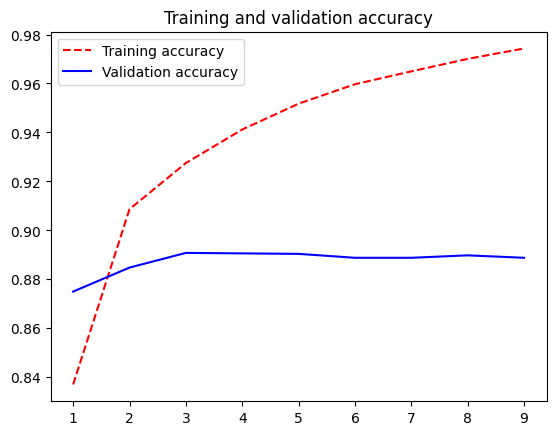

In [18]:
import matplotlib.pyplot as plt
accuracy= history.history["accuracy"]
val_accuracy= history.history["val_accuracy"]
epochs= range(1, len(accuracy)+1)
plt.plot(epochs,accuracy,"r--",label= "Training accuracy")
plt.plot(epochs, val_accuracy,"b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.show()

In [19]:
test_loss, test_acc= model.evaluate(bag_of_words_test_ds)
test_acc

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 673us/step - accuracy: 0.8867 - loss: 0.2834


0.8867200016975403

In [9]:
max_tokens=30_000
text_vectorization=layers.TextVectorization(
    max_tokens=max_tokens,
    split="whitespace",
    output_mode="multi_hot",
    ngrams=2,
)
train_ds_no_labels= train_ds.map(lambda x,y:x)
text_vectorization.adapt(train_ds_no_labels)
bigram_train_ds= train_ds.map(
    lambda x,y: (text_vectorization(x),y), num_parallel_calls=8
)
bigram_val_ds= val_ds.map(
    lambda x,y: (text_vectorization(x),y), num_parallel_calls=8
)
bigram_test_ds= test_ds.map(
    lambda x,y: (text_vectorization(x),y), num_parallel_calls=8
)

2026-06-17 15:22:02.541185: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [10]:
x,y= next(bigram_train_ds.as_numpy_iterator())
x.shape

(32, 30000)

In [11]:
text_vectorization.get_vocabulary()[100:108]

[np.str_('in a'),
 np.str_('most'),
 np.str_('him'),
 np.str_('dont'),
 np.str_('it was'),
 np.str_('one of'),
 np.str_('then'),
 np.str_('made')]

In [26]:
model= build_linear_classifier(max_tokens, "bigram_classifier")
model.fit(
    bigram_train_ds,
    validation_data=bigram_val_ds,
    epochs=10,
    callbacks=[early_stopping],
)
test_loss, test_acc= model.evaluate(bigram_test_ds)
test_acc

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8607 - loss: 0.3987 - val_accuracy: 0.8894 - val_loss: 0.3045
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 971us/step - accuracy: 0.9361 - loss: 0.2228 - val_accuracy: 0.8976 - val_loss: 0.2670
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9596 - loss: 0.1634 - val_accuracy: 0.8968 - val_loss: 0.2533
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 970us/step - accuracy: 0.9747 - loss: 0.1268 - val_accuracy: 0.8974 - val_loss: 0.2490
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 960us/step - accuracy: 0.9839 - loss: 0.1010 - val_accuracy: 0.8972 - val_loss: 0.2484
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 962us/step - accuracy: 0.9898 - loss: 0.0816 - val_accuracy: 0.8968 - val_loss: 0.2504
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 959us/step - accuracy: 0.9936 - loss: 0.0666 - val_accuracy: 0.8950 - val_loss: 0.2539
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - accuracy: 0.9018 - loss: 0.2502


0.9017999768257141

# Sequence models

In [12]:
max_length=600
max_tokens=30_000
text_vectorization= layers.TextVectorization(
    max_tokens=max_tokens,
    split="whitespace",
    output_mode="int",
    output_sequence_length=max_length
)
text_vectorization.adapt(train_ds_no_labels)
sequence_train_ds= train_ds.map(
    lambda x,y: (text_vectorization(x),y), num_parallel_calls=8
)
sequence_val_ds= val_ds.map(
    lambda x,y: (text_vectorization(x),y), num_parallel_calls=8
)
sequence_test_ds= test_ds.map(
    lambda x,y: (text_vectorization(x),y), num_parallel_calls=8
)

2026-06-17 15:22:12.965074: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [28]:
x,y= next(sequence_train_ds.as_numpy_iterator())
x.shape

(32, 600)

In [31]:
x

array([[5033, 3023,   15, ...,    0,    0,    0],
       [ 255,    2,   65, ...,    0,    0,    0],
       [ 358,   11,    7, ...,    0,    0,    0],
       ...,
       [  10,   62,  175, ...,    0,    0,    0],
       [  11, 2289, 1296, ...,    0,    0,    0],
       [  10,   26,  108, ...,    0,    0,    0]], shape=(32, 600))

In [13]:
from keras import ops

class OneHotEncoding(keras.Layer):
    def __init__(self,depth,**kwargs):
        super().__init__(**kwargs)
        self.depth=depth
    def call(self, inputs):
        flat_inputs= ops.reshape(ops.cast(inputs,"int"),[-1])
        one_hot_vectors= ops.eye(self.depth)
        outputs = ops.take(one_hot_vectors, flat_inputs,axis=0)
        return ops.reshape(outputs,ops.shape(inputs)+(self.depth,))
one_hot_encoding= OneHotEncoding(max_tokens)

In [36]:
x,u= next(sequence_train_ds.as_numpy_iterator())
one_hot_encoding(x).shape

TensorShape([32, 600, 30000])

In [14]:
hiddem_dims=64
inputs= keras.Input(shape=(max_length,),dtype="int32")
x= one_hot_encoding(inputs)
x= layers.Bidirectional(layers.LSTM(hiddem_dims))(x)
x= layers.Dropout(0.5)(x)
outputs= layers.Dense(1,activation="sigmoid")(x)
model= keras.Model(inputs, outputs, name="lstm_with_one_hot")
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)


In [15]:
model.summary()

Model: "lstm_with_one_hot"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 600)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ one_hot_encoding                │ (None, 600, 30000)     │             0 │
│ (OneHotEncoding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │    15,393,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,393,409 (58.72 MB)

 Trainable params: 15,393,409 (58.72 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(
    sequence_train_ds,
    validation_data=sequence_val_ds,
    epochs=10,
    callbacks=[early_stopping],
)
test_loss,test_acc= model.evaluate(sequence_test_ds)
test_acc

# gonna do word embeddings instead since one-hot encoding is bulky


In [18]:
hidden_dims=64
inputs= keras.Input(shape=(max_length,),dtype="int32")
x= keras.layers.Embedding(
    input_dim= max_tokens,
    output_dim= hiddem_dims,
    mask_zero=True,
)(inputs)
x=keras.layers.Bidirectional(keras.layers.LSTM(hiddem_dims))(x)
x= keras.layers.Dropout(0.5)(x)
outputs= keras.layers.Dense(1, activation="sigmoid")(x)
model= keras.Model(inputs,outputs,name="lstm_with_embedding")
model.compile(
    optimizer="adam",
    loss= "binary_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "lstm_with_embedding"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 600)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 600, 64)   │  1,920,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 600)       │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128)       │     66,048 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,986,177 (7.58 MB)

 Trainable params: 1,986,177 (7.58 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
early_stopping= keras.callbacks.EarlyStopping(
    monitor="val_loss",
    restore_best_weights=True,
    patience=2,
)

In [20]:
model.fit(
    sequence_train_ds,
    validation_data=sequence_val_ds,
    epochs=10,
    callbacks=[early_stopping],
)
test_loss,test_acc= model.evaluate(sequence_test_ds)
test_acc

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 80ms/step - accuracy: 0.8061 - loss: 0.4109 - val_accuracy: 0.8676 - val_loss: 0.3218
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.9201 - loss: 0.2120 - val_accuracy: 0.8772 - val_loss: 0.3109
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.9395 - loss: 0.1584 - val_accuracy: 0.8674 - val_loss: 0.3725
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 100ms/step - accuracy: 0.9711 - loss: 0.0832 - val_accuracy: 0.8760 - val_loss: 0.4275
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.8660 - loss: 0.3361


0.8660399913787842

# Continuos Bag of Words model

In [30]:
imdb_vocabulary= text_vectorization.get_vocabulary()
tokenize_no_padding= keras.layers.TextVectorization(
    vocabulary=imdb_vocabulary,
    split="whitespace",
    output_mode="int",
)

In [31]:
import tensorflow as tf

In [35]:
import tensorflow as tf
context_size=4
window_size=9
def window_data(token_ids):
    num_windows= tf.maximum(tf.size(token_ids)- context_size*2,0)
    windows= tf.range(window_size)[None,:]
    windows= windows + tf.range(num_windows)[:,None]
    windowed_tokens= tf.gather(token_ids, windows)
    return tf.data.Dataset.from_tensor_slices(windowed_tokens)

def split_label(window):
    left= window[:context_size]
    right= window[context_size+1:]
    bag= tf.concat((left,right),axis=0)
    label=window[4]
    return bag,label
dataset= keras.utils.text_dataset_from_directory(
    imdb_extract_dir/"train",batch_size=None
)
dataset= dataset.map(lambda x,y: x, num_parallel_calls=8)
dataset= dataset.map(tokenize_no_padding,num_parallel_calls=8)
dataset= dataset.interleave(window_data, cycle_length=8, num_parallel_calls=8)
dataset= dataset.map(split_label, num_parallel_calls=8)
    

Found 75000 files belonging to 3 classes.


In [36]:
hidden_dims=64
inputs= keras.Input(shape=(2*context_size,))
cbow_embdedding= layers.Embedding(
    max_tokens,
    hiddem_dims,
)
x= cbow_embdedding(inputs)
x= layers.GlobalAveragePooling1D()(x)
outputs= layers.Dense(max_tokens, activation="sigmoid")(x)
cbow_model= keras.Model(inputs,outputs)
cbow_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"]
)
cbow_model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 8, 64)          │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30000)          │     1,950,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,870,000 (14.76 MB)

 Trainable params: 3,870,000 (14.76 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
datasets= dataset.batch(1024).cache()
cbow_model.fit(datasets,epochs=4)

Epoch 1/4
16503/16503 ━━━━━━━━━━━━━━━━━━━━ 1587s 96ms/step - loss: 6.3344 - sparse_categorical_accuracy: 0.1021
Epoch 2/4
    1/16503 ━━━━━━━━━━━━━━━━━━━━ 28:02 102ms/step - loss: 5.8669 - sparse_categorical_accuracy: 0.1387

/opt/homebrew/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


16503/16503 ━━━━━━━━━━━━━━━━━━━━ 1753s 106ms/step - loss: 5.8828 - sparse_categorical_accuracy: 0.1288
Epoch 3/4
    1/16503 ━━━━━━━━━━━━━━━━━━━━ 29:18 107ms/step - loss: 5.6111 - sparse_categorical_accuracy: 0.1504

2026-06-17 17:20:09.083883: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


16503/16503 ━━━━━━━━━━━━━━━━━━━━ 1783s 108ms/step - loss: 5.7406 - sparse_categorical_accuracy: 0.1353
Epoch 4/4
16503/16503 ━━━━━━━━━━━━━━━━━━━━ 1808s 110ms/step - loss: 5.6701 - sparse_categorical_accuracy: 0.1376


In [39]:
inputs= keras.Input(shape=(max_length,))
lstm_embedding= layers.Embedding(
    input_dim= max_tokens,
    output_dim= hidden_dims,
    mask_zero=True,
)
x= lstm_embedding(inputs)
x= layers.Bidirectional(layers.LSTM(hidden_dims))(x)
x= layers.Dropout(0.5)(x)
outputs= layers.Dense(1, activation="sigmoid")(x)
model= keras.Model(inputs, outputs,name="lstm_with_cbow")

In [41]:
lstm_embedding.embeddings.assign(cbow_embdedding.embeddings)

<Variable path=embedding_3/embeddings, shape=(30000, 64), dtype=float32, value=[[-0.04612237  0.04536077  0.02915341 ... -0.01339716  0.02161874
  -0.04911965]
 [ 0.2833743   0.06313513 -0.05163873 ...  0.23725876 -0.25700808
   0.06824647]
 [-0.3633435  -0.61833227  0.07197447 ...  0.34191835  0.07862747
   0.2420158 ]
 ...
 [ 0.11881708 -0.13840695  0.26513883 ... -0.05669338  0.12742247
   0.03494093]
 [ 0.4682737  -0.7767495  -0.29320407 ... -0.3447746  -0.11392606
   0.17495488]
 [ 0.5585298  -0.38068894 -0.49752757 ...  0.42710724 -0.15851597
  -0.19617458]]>

In [42]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
    
)
model.fit(
    sequence_train_ds,
    validation_data= sequence_val_ds,
    epochs=10,
    callbacks= [early_stopping],
)
test_loss, test_acc= model.evaluate(sequence_test_ds)
test_acc

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 85ms/step - accuracy: 0.7924 - loss: 0.4435 - val_accuracy: 0.8394 - val_loss: 0.3710
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 69s 111ms/step - accuracy: 0.8579 - loss: 0.3401 - val_accuracy: 0.8490 - val_loss: 0.3498
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.8399 - loss: 0.3715


0.8398799896240234